# EDA dataset HetDDI (DrugBank + TWOSIDES)
Notebook này thực hiện EDA cơ bản và thực dụng cho dữ liệu trong dự án HetDDI, tập trung vào:
- Chất lượng dữ liệu
- Phân phối nhãn DDI
- Quan hệ giữa các biến/đặc trưng thống kê
- Phát hiện outlier
- Xuất báo cáo tóm tắt và dữ liệu đã làm sạch

Các phần bên dưới bám theo outline 10 mục EDA và áp dụng cho cả:
- `data/DRKG+DrugBank`
- `data/DRKG+TWOSIDES`

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn

     ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
     ---------------------------------------- 0.1/11.3 MB 3.3 MB/s eta 0:00:04
     - -------------------------------------- 0.4/11.3 MB 4.0 MB/s eta 0:00:03
     -- ------------------------------------- 0.8/11.3 MB 6.0 MB/s eta 0:00:02
     ------- -------------------------------- 2.0/11.3 MB 11.7 MB/s eta 0:00:01
     ------------- -------------------------- 4.0/11.3 MB 18.0 MB/s eta 0:00:01
     ---------------- ----------------------- 4.7/11.3 MB 18.6 MB/s eta 0:00:01
     ------------------- -------------------- 5.5/11.3 MB 19.4 MB/s eta 0:00:01
     ------------------------- -------------- 7.2/11.3 MB 20.8 MB/s eta 0:00:01
     ----------------------------- ---------- 8.4/11.3 MB 21.4 MB/s eta 0:00:01
     ----------------------------------- ---- 9.9/11.3 MB 23.5 MB/s eta 0:00:01
     --------------------------------------  11.2/11.3 MB 31.2 MB/s eta 0:00:01
     --------------------------------------  11.3/1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# 1) Thiết lập môi trường và import thư viện
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path(".")
DATASETS = {
    "DrugBank": ROOT / "data" / "DRKG+DrugBank",
    "TWOSIDES": ROOT / "data" / "DRKG+TWOSIDES",
}
OUT_DIR = ROOT / "output" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Datasets:", DATASETS)
print("Output dir:", OUT_DIR.resolve())

Datasets: {'DrugBank': WindowsPath('data/DRKG+DrugBank'), 'TWOSIDES': WindowsPath('data/DRKG+TWOSIDES')}
Output dir: C:\Users\Administrator\Desktop\HetDDI\output\eda


In [5]:
# 2) Đọc dữ liệu từ file và xem nhanh
COLS = {
    "nodes": ["node_id", "node_name", "node_type"],
    "edges": ["head", "relation", "tail"],
    "smiles": ["drug_id", "smiles"],
    "ddi": ["drug_a", "drug_b", "label"],
}


def read_tsv(path: Path, names):
    # File gốc dùng tab delimiter; không tách theo whitespace để tránh vỡ cột text có dấu cách.
    try:
        df = pd.read_csv(path, sep="\t", engine="python", names=names, header=None)
    except pd.errors.ParserError:
        # Fallback: đọc lại và chỉ giữ đúng số cột mong đợi.
        raw_df = pd.read_csv(path, sep="\t", engine="python", header=None, on_bad_lines="skip")
        df = raw_df.iloc[:, : len(names)].copy()
        df.columns = names
    return df


def load_dataset(ds_path: Path):
    nodes = read_tsv(ds_path / "nodes.tsv", COLS["nodes"])
    edges = read_tsv(ds_path / "edges.tsv", COLS["edges"])
    smiles = read_tsv(ds_path / "smiles.tsv", COLS["smiles"])
    ddi = read_tsv(ds_path / "ddi.tsv", COLS["ddi"])

    for df in [nodes, edges, smiles, ddi]:
        for c in df.columns:
            if c != "smiles" and c != "node_name":
                df[c] = pd.to_numeric(df[c], errors="coerce")

    return {"nodes": nodes, "edges": edges, "smiles": smiles, "ddi": ddi}


raw = {name: load_dataset(path) for name, path in DATASETS.items()}

for name, pack in raw.items():
    print(f"\n===== {name} =====")
    for key, df in pack.items():
        print(f"{key:6s} shape = {df.shape}")
    print("DDI head:")
    display(pack["ddi"].head(5))
    print("DDI tail:")
    display(pack["ddi"].tail(5))
    print("DDI sample:")
    display(pack["ddi"].sample(min(5, len(pack["ddi"])), random_state=42))


===== DrugBank =====
nodes  shape = (97243, 3)
edges  shape = (5719674, 3)
smiles shape = (1706, 2)
ddi    shape = (191427, 3)
DDI head:


,drug_a,drug_b,label
0,1173,281,0
1,625,281,0
2,1620,281,0
3,1119,281,0
4,1458,281,0


DDI tail:


,drug_a,drug_b,label
191422,260,308,85
191423,260,1616,85
191424,260,565,85
191425,240,260,85
191426,260,480,85


DDI sample:


...

,drug_a,drug_b,label
0,0,1,0
1,0,1,1
2,2,3,2
3,0,1,3
4,0,1,4


DDI tail:


,drug_a,drug_b,label
1979570,312,129,101
1979571,312,129,132
1979572,66,73,79
1979573,66,73,153
1979574,66,73,120


DDI sample:


,drug_a,drug_b,label
1803673,235,542,117
1692972,207,508,162
513177,334,145,41
612859,57,810,106
868641,484,54,161


In [6]:
# 3) Kiểm tra cấu trúc dữ liệu
summary_rows = []

for name, pack in raw.items():
    nodes, edges, smiles, ddi = pack["nodes"], pack["edges"], pack["smiles"], pack["ddi"]

    row = {
        "dataset": name,
        "num_nodes": len(nodes),
        "num_edges": len(edges),
        "num_smiles": len(smiles),
        "num_ddi_rows": len(ddi),
        "num_unique_drugs_in_ddi": pd.unique(ddi[["drug_a", "drug_b"]].to_numpy().ravel()).shape[0],
        "num_classes": ddi["label"].nunique(dropna=True),
        "ddi_dtype": str(ddi.dtypes.to_dict()),
        "ddi_shape": ddi.shape,
        "ddi_nunique_by_col": ddi.nunique(dropna=True).to_dict(),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

for name, pack in raw.items():
    print(f"\n--- info(): {name} / ddi ---")
    display(pack["ddi"].info())

,dataset,num_nodes,num_edges,num_smiles,num_ddi_rows,num_unique_drugs_in_ddi,num_classes,ddi_dtype,ddi_shape,ddi_nunique_by_col
0,DrugBank,97243,5719674,1706,191427,1706,86,"{'drug_a': dtype('int64'), 'drug_b': dtype('in...","(191427, 3)","{'drug_a': 1637, 'drug_b': 1611, 'label': 86}"
1,TWOSIDES,97246,5821665,1345,1979575,1345,200,"{'drug_a': dtype('int64'), 'drug_b': dtype('in...","(1979575, 3)","{'drug_a': 1184, 'drug_b': 1285, 'label': 200}"



--- info(): DrugBank / ddi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191427 entries, 0 to 191426
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   drug_a  191427 non-null  int64
 1   drug_b  191427 non-null  int64
 2   label   191427 non-null  int64
dtypes: int64(3)
memory usage: 4.4 MB


None


--- info(): TWOSIDES / ddi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1979575 entries, 0 to 1979574
Data columns (total 3 columns):
 #   Column  Dtype
---  ------  -----
 0   drug_a  int64
 1   drug_b  int64
 2   label   int64
dtypes: int64(3)
memory usage: 45.3 MB


None

,dataset,missing_rate,duplicate_rows,rows_before,rows_after_drop_duplicates
0,DrugBank,"{'drug_a': 0.0, 'drug_b': 0.0, 'label': 0.0}",0,191427,191427
1,TWOSIDES,"{'drug_a': 0.0, 'drug_b': 0.0, 'label': 0.0}",7669,1979575,1971906


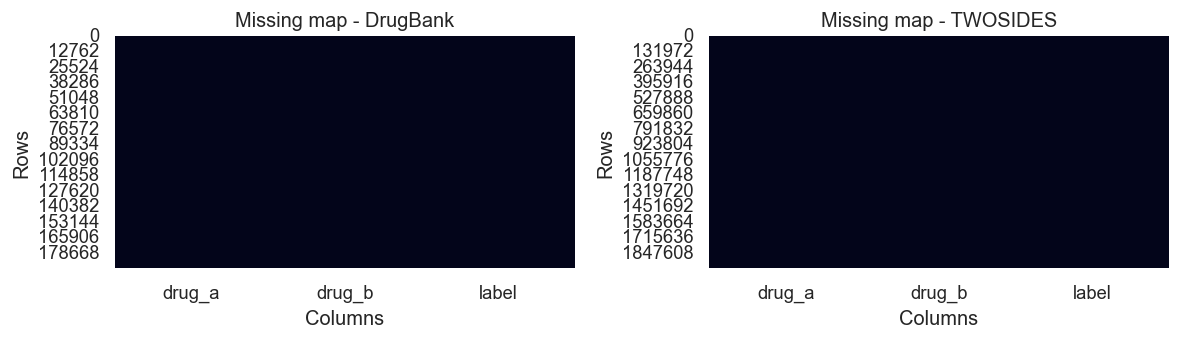

In [7]:
# 4) Đánh giá dữ liệu thiếu và bản ghi trùng
quality_rows = []

for name, pack in raw.items():
    ddi = pack["ddi"].copy()

    missing_rate = ddi.isna().mean().to_dict()
    dup_rows = int(ddi.duplicated().sum())

    # Bản cleaned cơ bản: drop duplicate dòng giống hệt nhau
    ddi_clean = ddi.drop_duplicates().copy()

    quality_rows.append(
        {
            "dataset": name,
            "missing_rate": missing_rate,
            "duplicate_rows": dup_rows,
            "rows_before": len(ddi),
            "rows_after_drop_duplicates": len(ddi_clean),
        }
    )

    raw[name]["ddi_clean"] = ddi_clean

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

# Missing map cơ bản cho ddi mỗi dataset
fig, axes = plt.subplots(1, 2, figsize=(10, 3), dpi=120)
for i, (name, pack) in enumerate(raw.items()):
    ddi = pack["ddi"]
    sns.heatmap(ddi.isna(), cbar=False, ax=axes[i])
    axes[i].set_title(f"Missing map - {name}")
    axes[i].set_xlabel("Columns")
    axes[i].set_ylabel("Rows")
plt.tight_layout()
plt.show()

In [8]:
# 5) Thống kê mô tả cho biến số
for name, pack in raw.items():
    ddi = pack["ddi_clean"]
    numeric_cols = ["drug_a", "drug_b", "label"]

    print(f"\n===== Numeric describe: {name} =====")
    display(ddi[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

    stats = pd.DataFrame(index=numeric_cols)
    stats["skew"] = ddi[numeric_cols].skew(numeric_only=True)
    stats["kurtosis"] = ddi[numeric_cols].kurtosis(numeric_only=True)
    stats["q1"] = ddi[numeric_cols].quantile(0.25)
    stats["q3"] = ddi[numeric_cols].quantile(0.75)
    stats["iqr"] = stats["q3"] - stats["q1"]
    display(stats)


===== Numeric describe: DrugBank =====


,count,mean,std,min,1%,5%,50%,95%,99%,max
drug_a,191427.0,745.780428,462.281455,0.0,31.0,83.0,702.0,1557.0,1678.0,1704.0
drug_b,191427.0,782.205332,480.751534,0.0,28.0,67.0,773.0,1556.0,1679.0,1705.0
label,191427.0,48.805236,18.985630,0.0,3.0,8.0,48.0,74.0,81.0,85.0


,skew,kurtosis,q1,q3,iqr
drug_a,0.261404,-1.013929,347.0,1097.0,750.0
drug_b,0.113108,-1.159620,358.0,1193.0,835.0
label,-0.685420,0.179910,46.0,66.0,20.0



===== Numeric describe: TWOSIDES =====


,count,mean,std,min,1%,5%,50%,95%,99%,max
drug_a,1971906.0,244.843592,197.535784,0.0,3.0,14.0,204.0,622.0,814.0,1342.0
drug_b,1971906.0,249.519733,200.571545,0.0,3.0,16.0,193.0,643.0,847.0,1344.0
label,1971906.0,98.751457,57.609217,0.0,2.0,10.0,98.0,189.0,197.0,199.0


,skew,kurtosis,q1,q3,iqr
drug_a,1.080541,0.897353,91.0,350.0,259.0
drug_b,1.131374,1.078111,97.0,368.0,271.0
label,0.012464,-1.198834,49.0,148.0,99.0


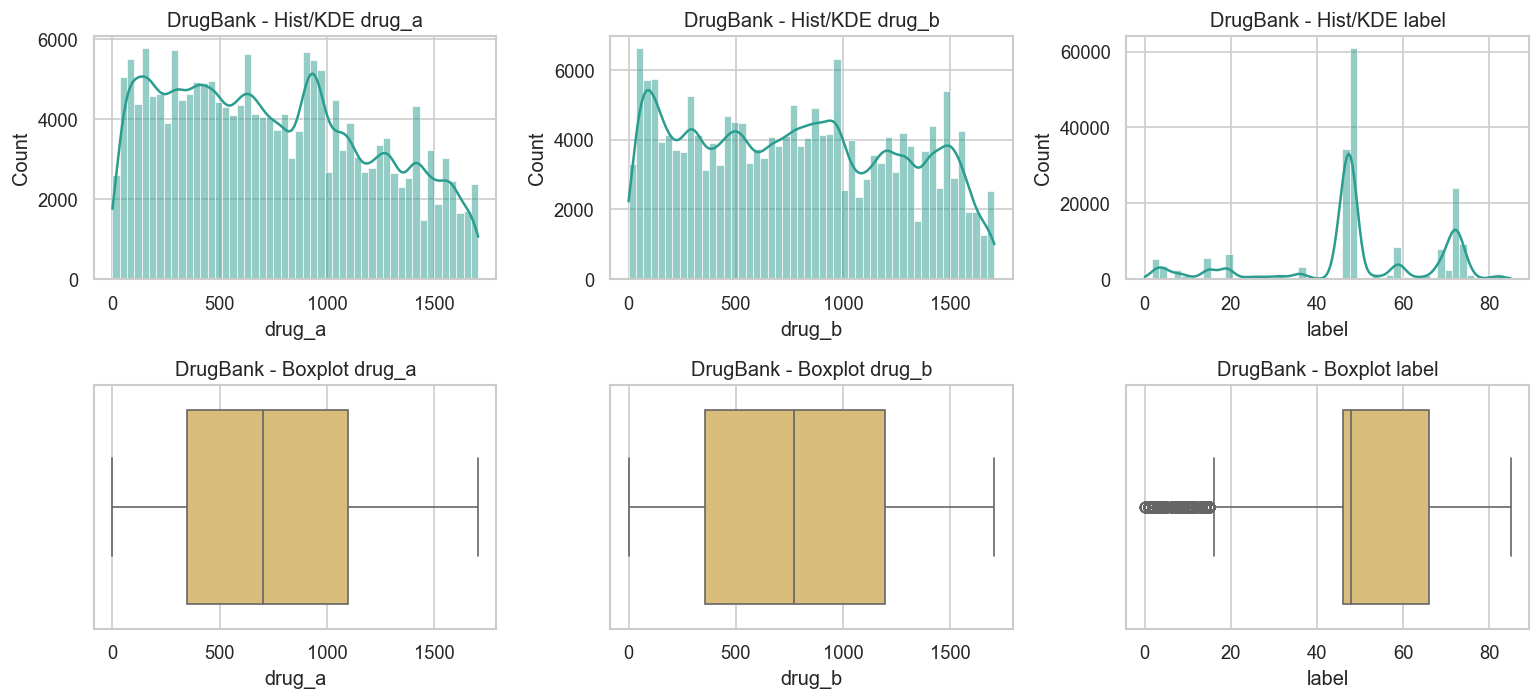

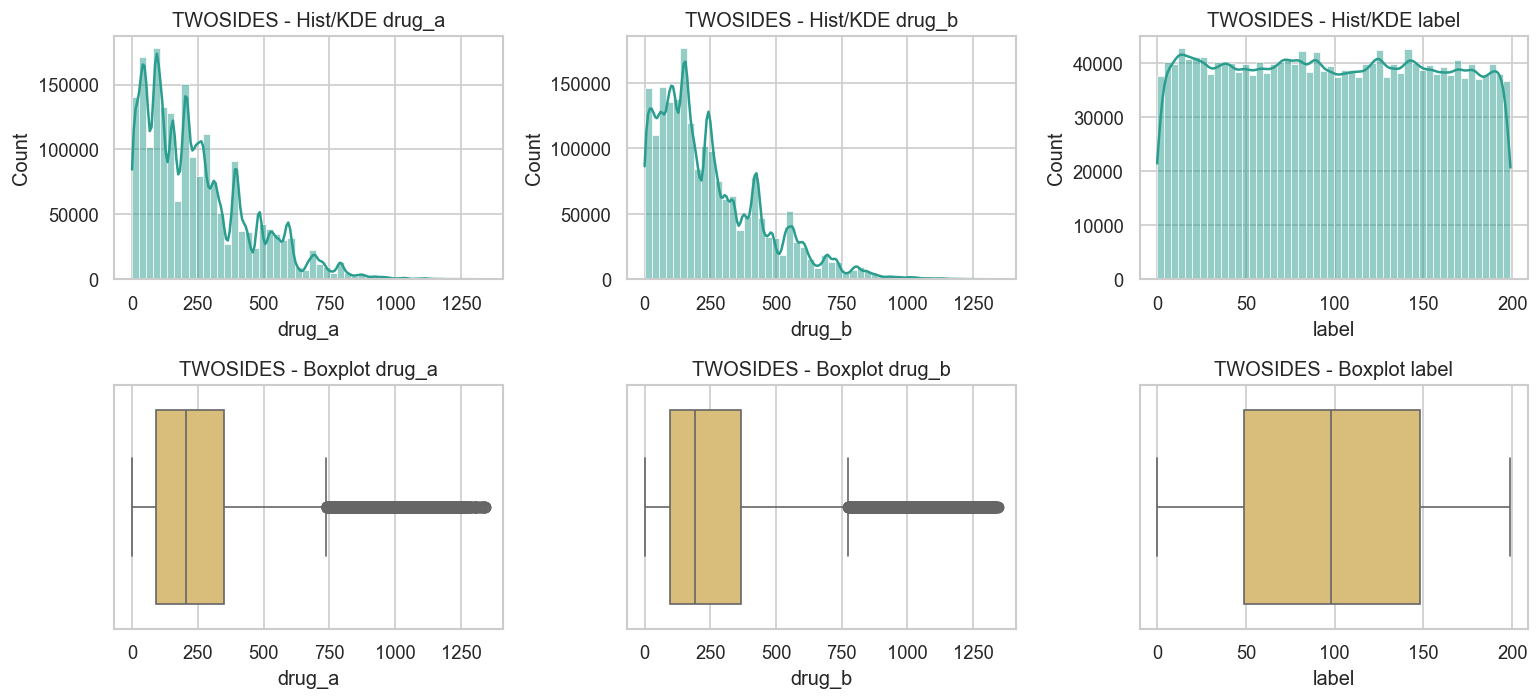

In [9]:
# 6) Phân tích đơn biến cho biến số (Histogram/Boxplot)
for name, pack in raw.items():
    ddi = pack["ddi_clean"]

    fig, axes = plt.subplots(2, 3, figsize=(13, 6), dpi=120)
    cols = ["drug_a", "drug_b", "label"]

    for j, c in enumerate(cols):
        sns.histplot(ddi[c], bins=50, kde=True, ax=axes[0, j], color="#2a9d8f")
        axes[0, j].set_title(f"{name} - Hist/KDE {c}")

        sns.boxplot(x=ddi[c], ax=axes[1, j], color="#e9c46a")
        axes[1, j].set_title(f"{name} - Boxplot {c}")

    plt.tight_layout()
    plt.show()


===== Label frequency: DrugBank =====


,count,ratio
label,,
48,60976,0.318534
46,34196,0.178637
72,23577,0.123164
74,9366,0.048927
59,8395,0.043855
69,7780,0.040642
19,6117,0.031955
15,5434,0.028387
3,4949,0.025853


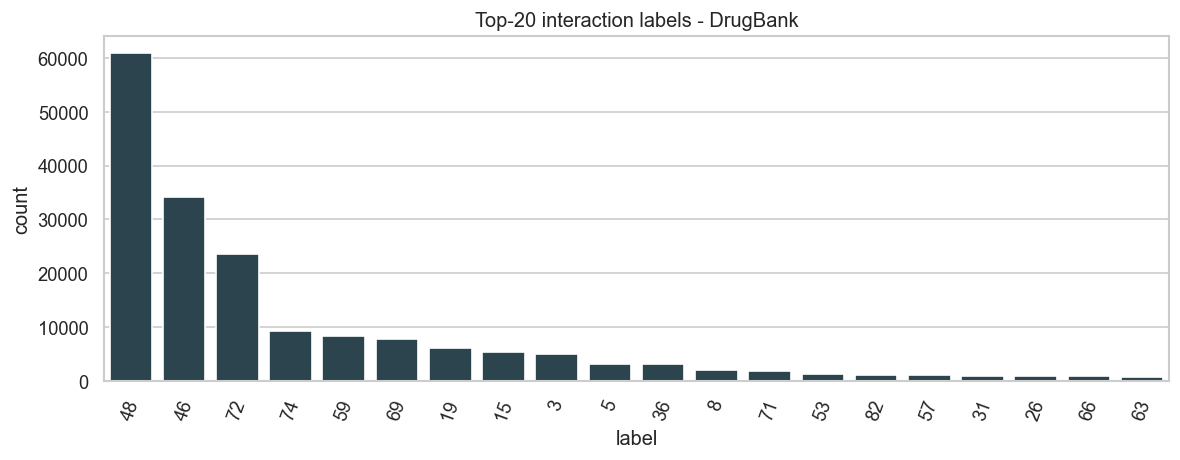

Long-tail ratio (classes with <=5 samples): 0.0000

===== Label frequency: TWOSIDES =====


,count,ratio
label,,
38,11154,0.005656
13,11144,0.005651
53,11121,0.005640
10,11094,0.005626
133,11063,0.005610
92,11051,0.005604
35,11040,0.005599
126,11022,0.005590
42,11008,0.005582


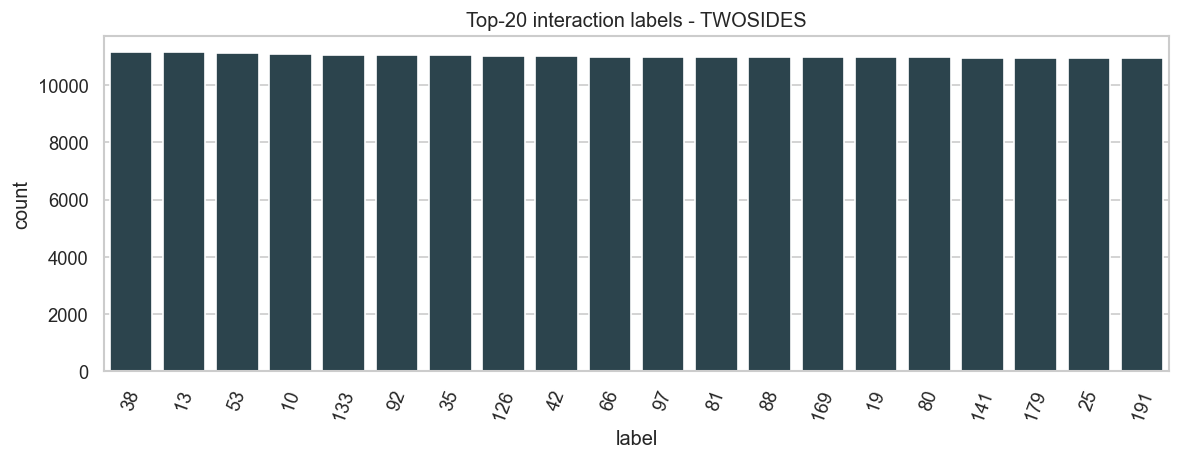

Long-tail ratio (classes with <=5 samples): 0.0000


In [10]:
# 7) Phân tích đơn biến cho biến phân loại (Bar chart)
for name, pack in raw.items():
    ddi = pack["ddi_clean"]
    label_freq = ddi["label"].value_counts()
    label_freq_norm = ddi["label"].value_counts(normalize=True)

    print(f"\n===== Label frequency: {name} =====")
    display(pd.DataFrame({"count": label_freq, "ratio": label_freq_norm}).head(20))

    top_n = min(20, len(label_freq))
    plt.figure(figsize=(10, 4), dpi=120)
    sns.barplot(x=label_freq.head(top_n).index.astype(str), y=label_freq.head(top_n).values, color="#264653")
    plt.title(f"Top-{top_n} interaction labels - {name}")
    plt.xlabel("label")
    plt.ylabel("count")
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

    long_tail_ratio = float((label_freq <= 5).sum() / max(1, len(label_freq)))
    print(f"Long-tail ratio (classes with <=5 samples): {long_tail_ratio:.4f}")


===== Correlation (DrugBank) =====
Pearson


,drug_a,drug_b,label
drug_a,1.000000,-0.003075,0.078710
drug_b,-0.003075,1.000000,0.086456
label,0.078710,0.086456,1.000000


Spearman


,drug_a,drug_b,label
drug_a,1.000000,-0.002249,0.071270
drug_b,-0.002249,1.000000,0.133456
label,0.071270,0.133456,1.000000


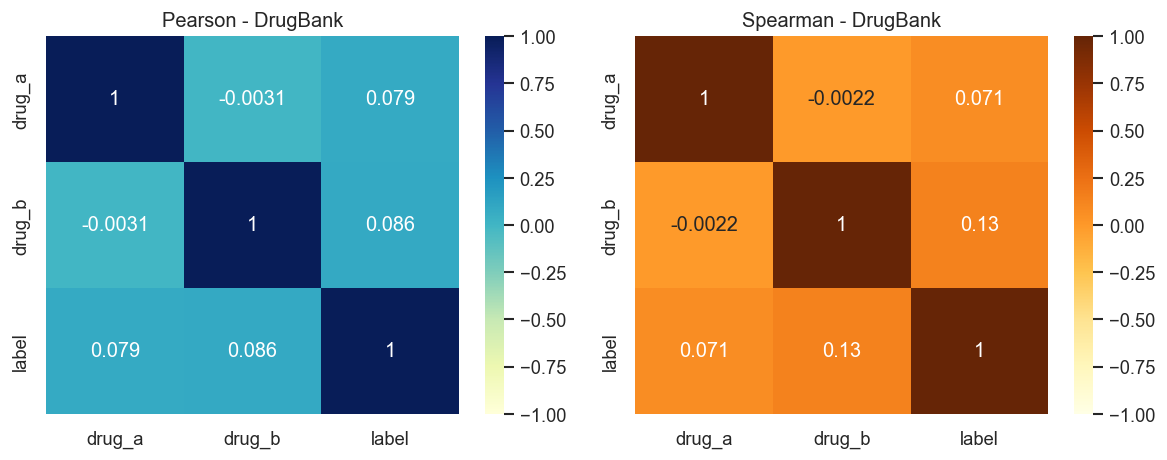

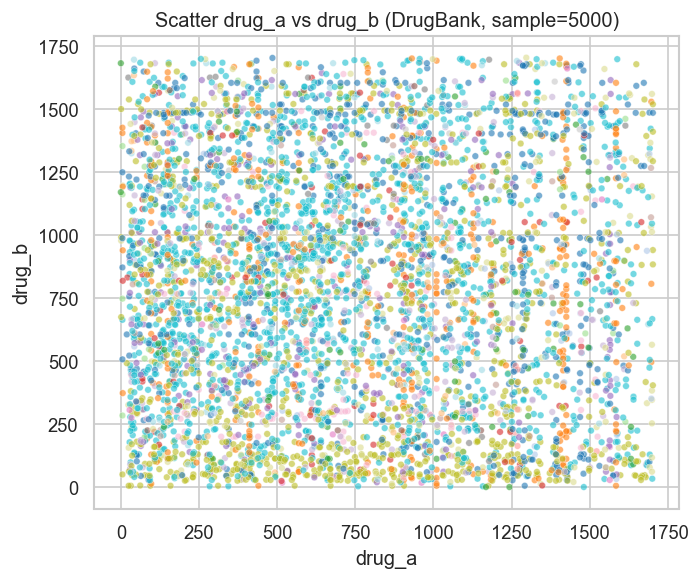


===== Correlation (TWOSIDES) =====
Pearson


,drug_a,drug_b,label
drug_a,1.000000,-0.020745,0.001043
drug_b,-0.020745,1.000000,0.006570
label,0.001043,0.006570,1.000000


Spearman


,drug_a,drug_b,label
drug_a,1.000000,-0.031093,0.001521
drug_b,-0.031093,1.000000,0.006863
label,0.001521,0.006863,1.000000


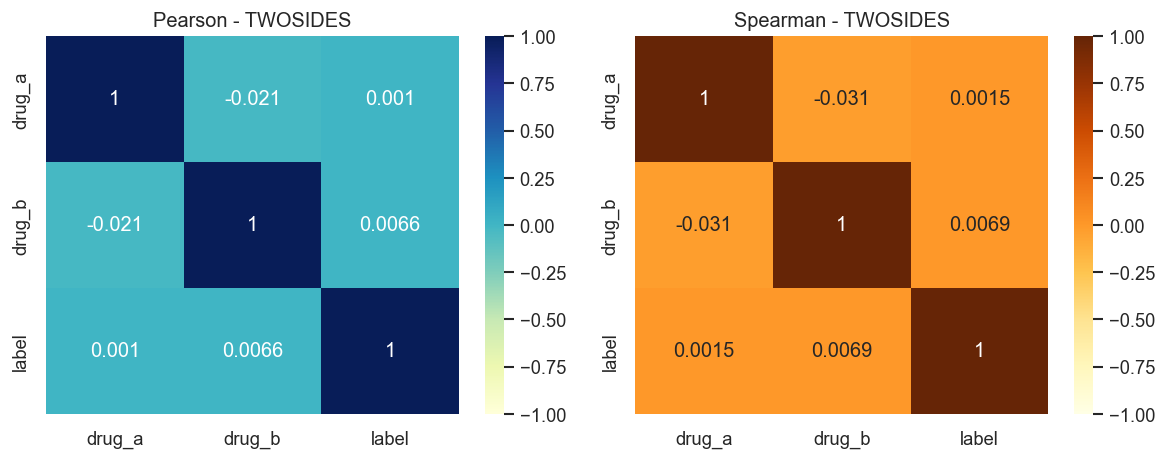

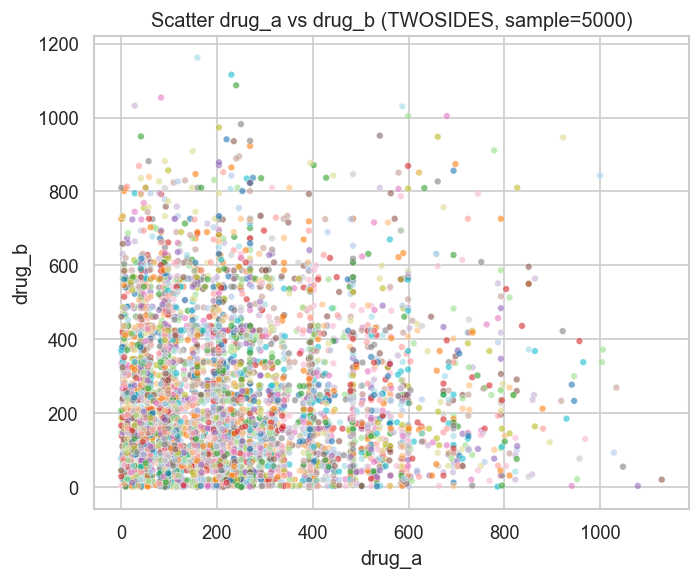

In [11]:
# 8) Phân tích tương quan và quan hệ giữa các biến
for name, pack in raw.items():
    ddi = pack["ddi_clean"]

    corr_pearson = ddi[["drug_a", "drug_b", "label"]].corr(method="pearson")
    corr_spearman = ddi[["drug_a", "drug_b", "label"]].corr(method="spearman")

    print(f"\n===== Correlation ({name}) =====")
    print("Pearson")
    display(corr_pearson)
    print("Spearman")
    display(corr_spearman)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
    sns.heatmap(corr_pearson, annot=True, cmap="YlGnBu", ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title(f"Pearson - {name}")
    sns.heatmap(corr_spearman, annot=True, cmap="YlOrBr", ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title(f"Spearman - {name}")
    plt.tight_layout()
    plt.show()

    sample_n = min(5000, len(ddi))
    sampled = ddi.sample(sample_n, random_state=42)
    plt.figure(figsize=(6, 5), dpi=120)
    sns.scatterplot(data=sampled, x="drug_a", y="drug_b", hue="label", palette="tab20", legend=False, s=16, alpha=0.6)
    plt.title(f"Scatter drug_a vs drug_b ({name}, sample={sample_n})")
    plt.tight_layout()
    plt.show()

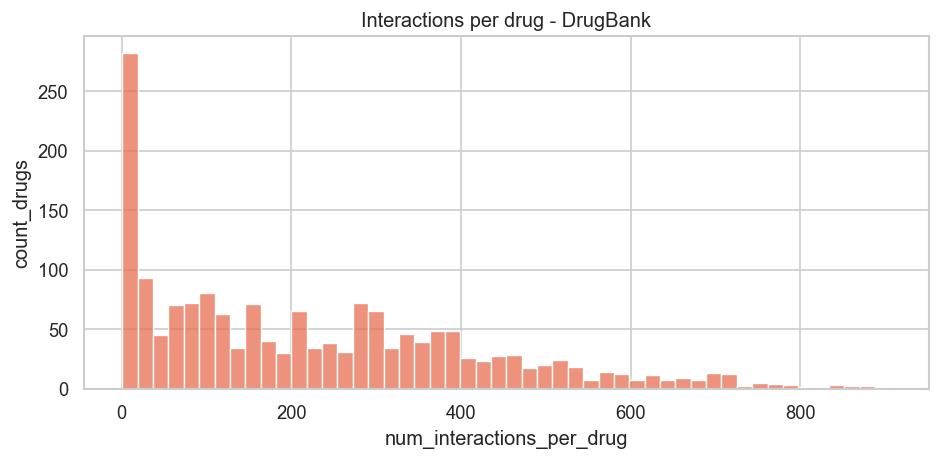

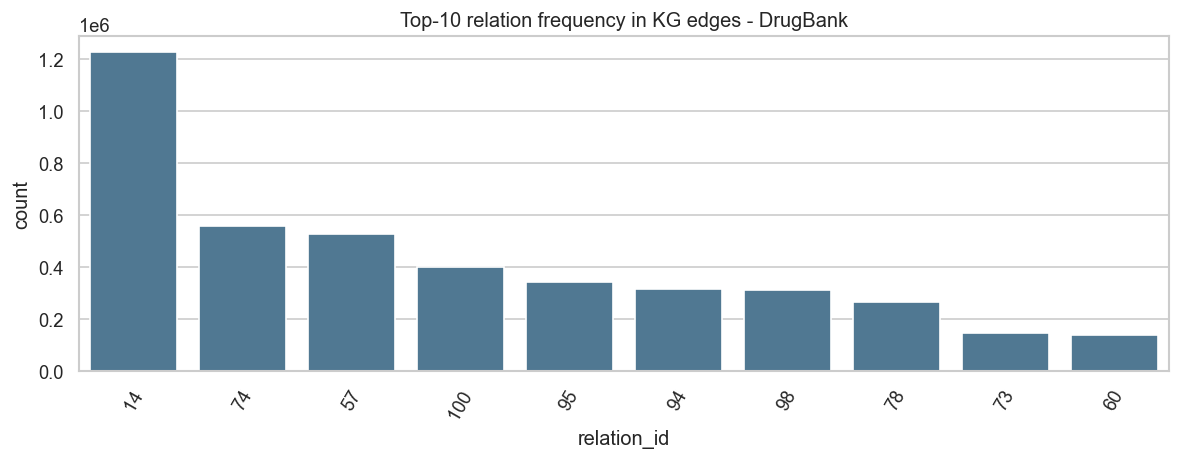

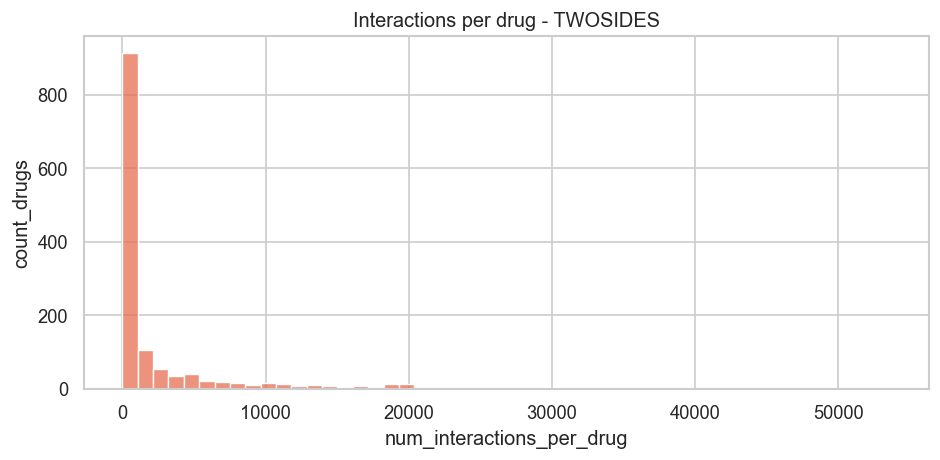

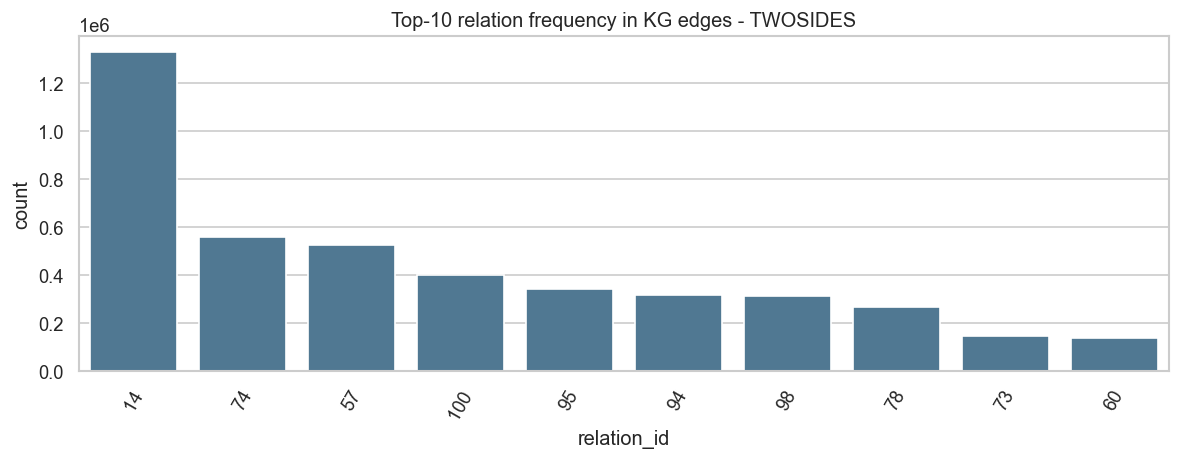

Extra metrics:


,dataset,exact_dup_abc,unordered_pair_dup,unordered_pair_label_dup,multi_label_pairs,multi_label_pair_ratio,symmetry_rate,self_interactions,ddi_drugs,smiles_drugs,ddi_smiles_overlap,ddi_nodes_overlap
0,DrugBank,0,117,0,117,0.0006,0.0000,0,1706,1706,1706,1706
1,TWOSIDES,0,1869744,7154,75641,0.7404,0.0073,140,1345,1345,1345,1345


Node type diagnostics:


,dataset,ddi_node_type_distribution,smiles_node_type_distribution
0,DrugBank,{0: 1706},{0: 1706}
1,TWOSIDES,{4: 1345},{4: 1345}


In [16]:
# Bổ sung: thống kê DDI chuyên sâu + coverage + graph relation (liên quan trực tiếp bài toán)
extra_rows = []
node_type_rows = []

for name, pack in raw.items():
    nodes, edges, smiles, ddi = pack["nodes"], pack["edges"], pack["smiles"], pack["ddi_clean"].copy()

    # Chuẩn hóa pair không hướng để phân tích duplicate và multi-label theo pair.
    ddi["u"] = ddi[["drug_a", "drug_b"]].min(axis=1)
    ddi["v"] = ddi[["drug_a", "drug_b"]].max(axis=1)

    exact_dup = int(ddi.duplicated(subset=["drug_a", "drug_b", "label"]).sum())
    unordered_pair_dup = int(ddi.duplicated(subset=["u", "v"]).sum())
    unordered_with_label_dup = int(ddi.duplicated(subset=["u", "v", "label"]).sum())

    # Với TWOSIDES, pair có nhiều label là hành vi hợp lệ (multi-label).
    pair_label_nunique = ddi.groupby(["u", "v"])["label"].nunique()
    multi_label_pairs = int((pair_label_nunique > 1).sum())
    multi_label_pair_ratio = float(multi_label_pairs / max(1, len(pair_label_nunique)))

    merge_sym = ddi.merge(
        ddi,
        left_on=["drug_a", "drug_b", "label"],
        right_on=["drug_b", "drug_a", "label"],
        how="inner",
    )
    symmetry_rate = len(merge_sym) / max(1, len(ddi))

    self_inter = int((ddi["drug_a"] == ddi["drug_b"]).sum())

    ddi_drugs = set(pd.unique(ddi[["drug_a", "drug_b"]].to_numpy().ravel()).tolist())
    smiles_drugs = set(smiles["drug_id"].dropna().astype(int).tolist())

    node_type_all = nodes[["node_id", "node_type"]].dropna().copy()
    node_type_all["node_id"] = node_type_all["node_id"].astype(int)
    node_type_all["node_type"] = node_type_all["node_type"].astype(int)

    ddi_type = node_type_all[node_type_all["node_id"].isin(ddi_drugs)]["node_type"].value_counts().sort_index()
    smiles_type = node_type_all[node_type_all["node_id"].isin(smiles_drugs)]["node_type"].value_counts().sort_index()

    ddi_node_ids_in_nodes = set(node_type_all["node_id"].tolist())
    ddi_node_overlap = len(ddi_drugs & ddi_node_ids_in_nodes)

    node_type_rows.append(
        {
            "dataset": name,
            "ddi_node_type_distribution": ddi_type.to_dict(),
            "smiles_node_type_distribution": smiles_type.to_dict(),
        }
    )

    rel_freq = edges["relation"].value_counts()
    top_rel = rel_freq.head(10)

    extra_rows.append(
        {
            "dataset": name,
            "exact_dup_abc": exact_dup,
            "unordered_pair_dup": unordered_pair_dup,
            "unordered_pair_label_dup": unordered_with_label_dup,
            "multi_label_pairs": multi_label_pairs,
            "multi_label_pair_ratio": round(multi_label_pair_ratio, 4),
            "symmetry_rate": round(float(symmetry_rate), 4),
            "self_interactions": self_inter,
            "ddi_drugs": len(ddi_drugs),
            "smiles_drugs": len(smiles_drugs),
            "ddi_smiles_overlap": len(ddi_drugs & smiles_drugs),
            "ddi_nodes_overlap": ddi_node_overlap,
        }
    )

    # interactions per drug
    degree_like = pd.concat([ddi["drug_a"], ddi["drug_b"]], axis=0).value_counts()
    plt.figure(figsize=(8, 4), dpi=120)
    sns.histplot(degree_like.values, bins=50, color="#e76f51")
    plt.title(f"Interactions per drug - {name}")
    plt.xlabel("num_interactions_per_drug")
    plt.ylabel("count_drugs")
    plt.tight_layout()
    plt.show()

    # relation frequency bar
    plt.figure(figsize=(10, 4), dpi=120)
    sns.barplot(x=top_rel.index.astype(str), y=top_rel.values, color="#457b9d")
    plt.title(f"Top-10 relation frequency in KG edges - {name}")
    plt.xlabel("relation_id")
    plt.ylabel("count")
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

extra_df = pd.DataFrame(extra_rows)
node_type_df = pd.DataFrame(node_type_rows)

print("Extra metrics:")
display(extra_df)
print("Node type diagnostics:")
display(node_type_df)

In [13]:
# 9) Phát hiện ngoại lệ (IQR/Z-score)
def iqr_outlier_mask(s: pd.Series):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (s < low) | (s > high)


def zscore_outlier_mask(s: pd.Series, thr: float = 3.0):
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series([False] * len(s), index=s.index)
    z = (s - s.mean()) / std
    return z.abs() > thr


outlier_rows = []
for name, pack in raw.items():
    ddi = pack["ddi_clean"].copy()
    for c in ["drug_a", "drug_b", "label"]:
        iqr_mask = iqr_outlier_mask(ddi[c])
        z_mask = zscore_outlier_mask(ddi[c], thr=3.0)
        outlier_rows.append(
            {
                "dataset": name,
                "column": c,
                "iqr_outliers": int(iqr_mask.sum()),
                "iqr_ratio": float(iqr_mask.mean()),
                "zscore_outliers": int(z_mask.sum()),
                "zscore_ratio": float(z_mask.mean()),
            }
        )

outlier_df = pd.DataFrame(outlier_rows)
display(outlier_df)

,dataset,column,iqr_outliers,iqr_ratio,zscore_outliers,zscore_ratio
0,DrugBank,drug_a,0,0.000000,0,0.000000
1,DrugBank,drug_b,0,0.000000,0,0.000000
2,DrugBank,label,18851,0.098476,0,0.000000
3,TWOSIDES,drug_a,43185,0.021900,16382,0.008308
4,TWOSIDES,drug_b,40202,0.020387,18613,0.009439
5,TWOSIDES,label,0,0.000000,0,0.000000


In [ ]:
# Split sanity check theo kịch bản gần với s1/s2/s3
from sklearn.model_selection import KFold


def _fold_report(train_df: pd.DataFrame, test_df: pd.DataFrame, fold_id: int, scenario: str):
    tr_drugs = set(pd.unique(train_df[["drug_a", "drug_b"]].to_numpy().ravel()).tolist())
    te_drugs = set(pd.unique(test_df[["drug_a", "drug_b"]].to_numpy().ravel()).tolist())

    tr_label = train_df["label"].value_counts(normalize=True)
    te_label = test_df["label"].value_counts(normalize=True)
    all_labels = sorted(set(tr_label.index) | set(te_label.index))
    drift = float(
        np.abs(
            np.array([tr_label.get(l, 0) for l in all_labels])
            - np.array([te_label.get(l, 0) for l in all_labels])
        ).mean()
    )

    return {
        "scenario": scenario,
        "fold": fold_id,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "train_drugs": len(tr_drugs),
        "test_drugs": len(te_drugs),
        "drug_overlap": len(tr_drugs & te_drugs),
        "label_dist_drift_mean_abs": drift,
    }


def split_sanity_by_scenario(ddi_df: pd.DataFrame, n_splits: int = 5, seed: int = 42):
    ddi_df = ddi_df.copy()
    ddi_df["u"] = ddi_df[["drug_a", "drug_b"]].min(axis=1)
    ddi_df["v"] = ddi_df[["drug_a", "drug_b"]].max(axis=1)

    records = []

    # s1-like: random row split
    kf_rows = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    idx = np.arange(len(ddi_df))
    for i, (tr_idx, te_idx) in enumerate(kf_rows.split(idx)):
        records.append(_fold_report(ddi_df.iloc[tr_idx], ddi_df.iloc[te_idx], i, "s1_random_rows"))

    # s2-like: split theo unordered pair (pair-disjoint)
    pair_df = ddi_df[["u", "v"]].drop_duplicates().reset_index(drop=True)
    kf_pair = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for i, (tr_idx, te_idx) in enumerate(kf_pair.split(pair_df)):
        tr_pairs = set(map(tuple, pair_df.iloc[tr_idx][["u", "v"]].to_numpy()))
        te_pairs = set(map(tuple, pair_df.iloc[te_idx][["u", "v"]].to_numpy()))
        train = ddi_df[ddi_df[["u", "v"]].apply(tuple, axis=1).isin(tr_pairs)]
        test = ddi_df[ddi_df[["u", "v"]].apply(tuple, axis=1).isin(te_pairs)]
        records.append(_fold_report(train, test, i, "s2_pair_disjoint"))

    # s3-like: split theo drug (drug-disjoint, nghiêm ngặt hơn)
    drug_ids = np.array(sorted(set(pd.unique(ddi_df[["drug_a", "drug_b"]].to_numpy().ravel()).tolist())))
    kf_drug = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for i, (tr_idx, te_idx) in enumerate(kf_drug.split(drug_ids)):
        tr_drugs = set(drug_ids[tr_idx].tolist())
        te_drugs = set(drug_ids[te_idx].tolist())

        # train/test chỉ giữ cạnh mà cả 2 đầu mút nằm trong tập drug tương ứng
        train = ddi_df[ddi_df["drug_a"].isin(tr_drugs) & ddi_df["drug_b"].isin(tr_drugs)]
        test = ddi_df[ddi_df["drug_a"].isin(te_drugs) & ddi_df["drug_b"].isin(te_drugs)]
        records.append(_fold_report(train, test, i, "s3_drug_disjoint"))

    return pd.DataFrame(records)


split_summary_all = []
for name, pack in raw.items():
    print(f"\n===== Split sanity by scenario - {name} =====")
    split_df = split_sanity_by_scenario(pack["ddi_clean"], n_splits=5, seed=42)
    split_df.insert(0, "dataset", name)
    split_summary_all.append(split_df)

    display(split_df)
    display(split_df.groupby("scenario").agg({
        "train_rows": "mean",
        "test_rows": "mean",
        "drug_overlap": "mean",
        "label_dist_drift_mean_abs": "mean",
    }).reset_index())

split_summary_all = pd.concat(split_summary_all, ignore_index=True)


===== Split sanity by scenario - DrugBank =====


,dataset,scenario,fold,train_rows,test_rows,train_drugs,test_drugs,drug_overlap,label_dist_drift_mean_abs
0,DrugBank,s1_random_rows,0,153141,38286,1691,1590,1575,0.000313
1,DrugBank,s1_random_rows,1,153141,38286,1691,1598,1583,0.000294
2,DrugBank,s1_random_rows,2,153142,38285,1690,1605,1589,0.000338
3,DrugBank,s1_random_rows,3,153142,38285,1685,1598,1577,0.000231
4,DrugBank,s1_random_rows,4,153142,38285,1694,1589,1577,0.000294
5,DrugBank,s2_pair_disjoint,0,153137,38290,1688,1591,1573,0.000228
6,DrugBank,s2_pair_disjoint,1,153135,38292,1695,1597,1586,0.000254
7,DrugBank,s2_pair_disjoint,2,153139,38288,1688,1593,1575,0.000284
8,DrugBank,s2_pair_disjoint,3,153151,38276,1685,1615,1594,0.000231
9,DrugBank,s2_pair_disjoint,4,153146,38281,1695,1599,1588,0.000300


,scenario,train_rows,test_rows,drug_overlap,label_dist_drift_mean_abs
0,s1_random_rows,153141.6,38285.4,1580.2,0.000294
1,s2_pair_disjoint,153141.6,38285.4,1583.2,0.000259
2,s3_drug_disjoint,122521.2,7665.0,0.0,0.003179



===== Split sanity by scenario - TWOSIDES =====


In [ ]:
# 10) Tạo báo cáo EDA tóm tắt và lưu kết quả
split_summary_path = OUT_DIR / "split_sanity_summary.csv"

report = (
    summary_df
    .merge(quality_df, on="dataset", how="left")
    .merge(extra_df, on="dataset", how="left")
)

# Tổng hợp nhanh chất lượng split theo từng scenario.
split_agg = (
    split_summary_all
    .groupby(["dataset", "scenario"], as_index=False)
    .agg({
        "drug_overlap": "mean",
        "label_dist_drift_mean_abs": "mean",
        "test_rows": "mean",
    })
)

report_path = OUT_DIR / "eda_summary.csv"
report.to_csv(report_path, index=False)
split_summary_all.to_csv(split_summary_path, index=False)

for name, pack in raw.items():
    cleaned_path = OUT_DIR / f"{name.lower()}_ddi_cleaned.csv"
    pack["ddi_clean"].to_csv(cleaned_path, index=False)

print("Saved:")
print("-", report_path)
print("-", split_summary_path)
for name in raw:
    print("-", OUT_DIR / f"{name.lower()}_ddi_cleaned.csv")

print("\nMain report")
display(report)
print("\nSplit scenario aggregate")
display(split_agg)

Saved:
- output\eda\eda_summary.csv
- output\eda\drugbank_ddi_cleaned.csv
- output\eda\twosides_ddi_cleaned.csv


,dataset,num_nodes,num_edges,num_smiles,num_ddi_rows,num_unique_drugs_in_ddi,num_classes,ddi_dtype,ddi_shape,ddi_nunique_by_col,missing_rate,duplicate_rows,rows_before,rows_after_drop_duplicates,exact_dup_abc,unordered_pair_dup,symmetry_rate,self_interactions,ddi_drugs,smiles_drugs,node_type0_drugs,ddi_smiles_overlap,ddi_node_type0_overlap
0,DrugBank,97243,5719674,1706,191427,1706,86,"{'drug_a': dtype('int64'), 'drug_b': dtype('in...","(191427, 3)","{'drug_a': 1637, 'drug_b': 1611, 'label': 86}","{'drug_a': 0.0, 'drug_b': 0.0, 'label': 0.0}",0,191427,191427,0,117,0.0000,0,1706,1706,1706,1706,1706
1,TWOSIDES,97246,5821665,1345,1979575,1345,200,"{'drug_a': dtype('int64'), 'drug_b': dtype('in...","(1979575, 3)","{'drug_a': 1184, 'drug_b': 1285, 'label': 200}","{'drug_a': 0.0, 'drug_b': 0.0, 'label': 0.0}",7669,1979575,1971906,0,1869744,0.0073,140,1345,1345,400,1345,0


## Kết luận nhanh và checklist trước khi train model
### Các điểm đã ổn
- Parse dữ liệu ổn định theo tab delimiter, không còn lỗi parser.
- Missing gần như bằng 0 cho các cột chính của DDI.
- Có báo cáo tổng hợp ở `output/eda/eda_summary.csv` và split scenario ở `output/eda/split_sanity_summary.csv`.

### Cần chốt trước khi train
- Kiểm tra và chọn đúng protocol split: `s1_random_rows`, `s2_pair_disjoint`, `s3_drug_disjoint` (không dùng random row split để báo cáo chính).
- Với TWOSIDES, coi `multi_label_pairs` là tín hiệu dữ liệu multi-label hợp lệ, không coi là duplicate lỗi.
- Xác nhận mapping `node_type` thực sự đại diện cho drug subset nào trước khi lọc node từ KG.
- Đồng bộ dữ liệu train với dữ liệu đã clean (nếu quyết định dùng bản cleaned).

### Model readiness checklist
- [ ] Đã fix protocol split đúng với mục tiêu thí nghiệm
- [ ] Đã xác nhận leakage theo `drug_overlap` ở mức chấp nhận được
- [ ] Đã chọn chiến lược xử lý long-tail labels (class-weight/focal/sampling)
- [ ] Đã thống nhất dùng dữ liệu gốc hay dữ liệu cleaned
- [ ] Đã xác nhận mapping node type và độ phủ feature KG + SMILES